In [1]:
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import pickle

import matplotlib.pyplot as plt
from matplotlib.pyplot import figure, show, savefig, close
import matplotlib.font_manager as fm
import itertools

import taurex
import xarray as xr
import os
import pandas as pd
import astropy

from taurex.cache import OpacityCache, CIACache
OpacityCache().clear_cache()
OpacityCache().set_opacity_path('./xsec/')
CIACache().set_cia_path('./cia/')

from taurex.temperature import TemperatureFile
from taurex.chemistry import TaurexChemistry
from taurex.chemistry import ConstantGas

from taurex.planet import Planet
from taurex.stellar import BlackbodyStar, PhoenixStar

from taurex.model import EmissionModel, TransmissionModel
from taurex.pressure import SimplePressureProfile

from taurex.contributions import AbsorptionContribution
from taurex.contributions import CIAContribution
from taurex.contributions import RayleighContribution

from taurex.binning import FluxBinner
from ipywidgets import *

Numba not installed, using numpy instead


In [2]:
h2o_xsec = OpacityCache()['H2O']
ch4_xsec = OpacityCache()['CH4']
co2_xsec = OpacityCache()['CO2']
co_xsec = OpacityCache()['CO']
nh3_xsec = OpacityCache()['NH3']
o2_xsec = OpacityCache()['O2']
so2_xsec = OpacityCache()['SO2']

interactive(children=(FloatSlider(value=1500.0, description='temperature', max=4000.0, min=300.0, step=50.0), …

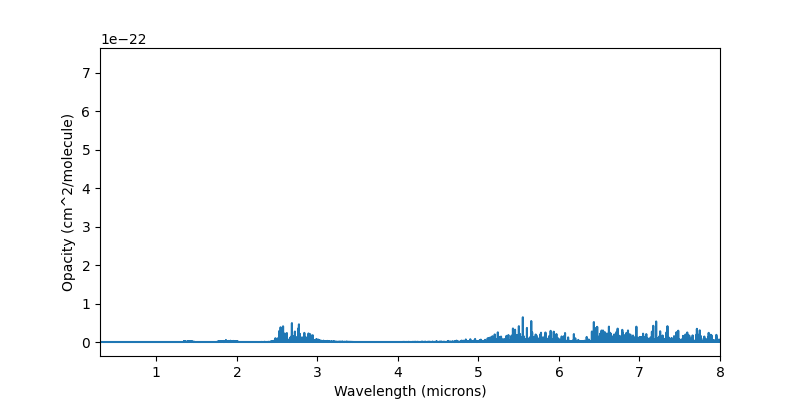

In [18]:
%matplotlib widget

fig = figure(figsize=(8, 4), dpi=100)
frame = fig.add_subplot(1, 1, 1)

wavenumber = h2o_xsec.wavenumberGrid
frame.set_xlim(0.3, 8) #cover Ariel wavelength range
frame.set_xlabel("Wavelength (microns)")
frame.set_ylabel("Opacity (cm^2/molecule)")

xsec, = frame.plot(1e4/wavenumber, h2o_xsec.opacity(1500, 1.0*1e5)) #micron, cm^2/molecule | Kelvin, Pa

def update_cross(temperature=1500.0, pressure_bar=1.0):
    pressure_pa = pressure_bar * 1e5  # convert bar to Pa
    xsec.set_ydata(h2o_xsec.opacity(temperature, pressure_pa))
    frame.relim()
    frame.autoscale_view()
    fig.canvas.draw()

interact(update_cross, temperature=(300.0, 4000.0, 50), pressure_bar=(0.001, 3000.0, 1));

In [16]:
#find in current plot shown the x value of the highest point in the plot
x_max = 1e4/wavenumber[np.argmax(h2o_xsec.opacity(2400, 10*1e5))]

print(f"The x value of the highest point in the plot is: {x_max} microns")

The x value of the highest point in the plot is: 33.000977439791164 microns
